For Foot 9.11 
Equilibrium number of Atoms in a 3D MOT

In [411]:
import handcalcs.render
import numpy as np
from scipy.constants import speed_of_light, Boltzmann, pi
import matplotlib.pyplot as plt
from math import pi, sqrt, exp
import forallpeople as si
from scipy.integrate import quad
import sympy as sp


In [412]:
si.environment('default', top_level=True)
handcalcs.set_option('use_scientific_notation', True)
handcalcs.set_option('display_precision', 6)
handcalcs.set_option("custom_symbols", {"v_bar": "\\bar{v}", "N_trap_dot": "\\dot{N}"})

In [413]:
v, vp, vc , Vapour, Area, vbar, sig= sp.symbols('v vp vc Vapour Area vbar sig', real=True, positive=True)

In [414]:
%%render params
D = 2e-2 *m#2 cm beam diameter
v_c = 25*m/s #capture velocity
N = 1e26 /m**3#vapour number density
sigma = 2e-17 *m**2# collision cross section

M_Rb = 1.443*1e-25 *kg # kg mass of Rb 87
hbar = 1.054571817e-34 * (kg * m**2 / s)
k_B = 1.380649e-23 * si.kg * si.m**2 / (si.s**2 * si.K)
A = 6*D**2 #MOT Surface area
T = 300 * K #temperature of the vapour
C = k_B*T/M_Rb #constant for the Maxwell-Boltzmann distribution
v_bar = sqrt(8*C.value/pi) *m/s #mean speed of the atom
v_p = sqrt(2*C.value) *m/s #most probable speed of the atoms

<IPython.core.display.Latex object>

In [415]:
def f_sym(v): #normalized Maxwell-Boltzmann distribution
    a= 1/vp**2
    return 4*sp.pi*v**2*(a/sp.pi)**sp.Rational(3, 2)*sp.exp(-a*v**2)
def f_np(v): #normalized Maxwell-Boltzmann distribution
    return 4*sp.pi*v**2*(1/(2*sp.pi*C.value))**sp.Rational(3, 2)*np.exp(-v**2/(2*C.value))
def Number_sym(v):
    return sp.Rational(1, 4)*Vapour*v*Area*f_sym(v)
def Number_np(v):
    return 1/4*N*v*A.value*f_np(v)

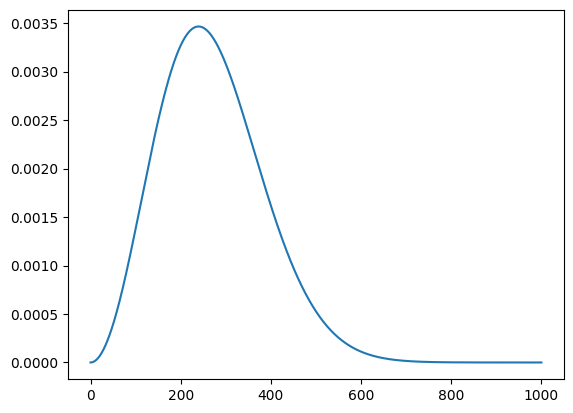

In [416]:
speeds = np.linspace(0, 1000, 1000)
plt.plot(speeds, f_np(speeds), label='Maxwell-Boltzmann Distribution')
plt.show()

In [417]:
#Check Normalization of the Maxwell-Boltzmann distribution
f_norm = sp.integrate(f_sym(v), (v, 0, sp.oo))
f_norm

1

In [418]:
# To be honest I dont totally understand the code below

sp.pprint(sp.simplify(Number_sym(v)))

R_exact = sp.integrate(Number_sym(v), (v, 0 , vc))
R_exact.simplify()

# v = (vc / vp)^2, our small parameter
R_exact_v = R_exact.subs(vc, sp.sqrt(v) * vp)

R_series = sp.series(R_exact_v, v, 0, 3).removeO()   # keep leading nonzero order
R_series = sp.simplify(R_series.subs(v, vc**2 / vp**2))
print("\nLeading-order (v_c << v_p) approximation:")
sp.pprint(R_series)

                  2 
                -v  
                ────
                  2 
             3  vp  
Area⋅Vapour⋅v ⋅ℯ    
────────────────────
            3       
       √π⋅vp        

Leading-order (v_c << v_p) approximation:
              4
Area⋅Vapour⋅vc 
───────────────
          3    
   4⋅√π⋅vp     


In [419]:
#Equilibrium MOT number
N_eq = sp.simplify(R_series / (Vapour * vbar * sig))
N_eq


Area*vc**4/(4*sqrt(pi)*sig*vbar*vp**3)

In [420]:
%%render sympy
Vapour = N
Area = A
vbar = v_bar
sig = sigma
vc = v_c
vp = v_p

Eq = N_eq

<IPython.core.display.Latex object>

In [421]:
print('Equilibrium MOT number:', round(Eq /1e6, 2), 'million atoms')

Equilibrium MOT number: 1777.93 million atoms


In [422]:
%%render
tau = 1/(N*v_bar*sigma)

<IPython.core.display.Latex object>

1.8493999605763545e-12


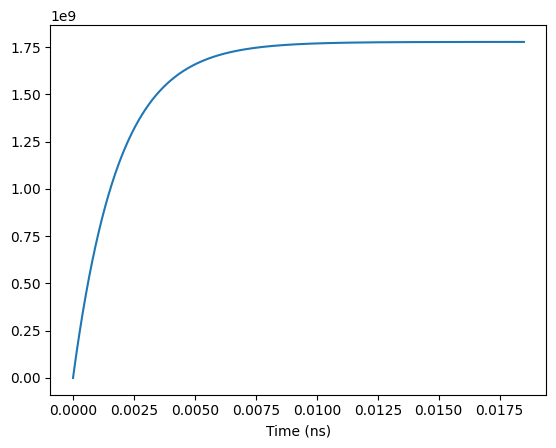

In [424]:
pico_tau = float(tau)/1e12
print(pico_tau)
def N_trap(t):
    return float(Eq)*(1-np.exp(-t/pico_tau))
time = np.linspace(0, 10*pico_tau, 10000)
plt.plot(time*1e9, N_trap(time))
plt.xlabel('Time (ns)')
plt.show()